# Chapter 1 — How big is the plane-wave basis?

Companion notebook to Chapter 1. The wavefunction cutoff `ecutwfc`
keeps every plane wave with $\tfrac{1}{2}|\mathbf{k}+\mathbf{G}|^2 <
E_\text{cut}$. The number of such $\mathbf{G}$-vectors equals the number
of points in a sphere of radius $\sqrt{2 E_\text{cut}}$, so it should
grow as $E_\text{cut}^{3/2}$.

We test that against the GaAs smooth-grid sizes in
`code/01-plane-wave-dft/npw_sweep.dat`. Requirements: `numpy`, `matplotlib`.

In [1]:
import numpy as np
from pathlib import Path

ec, npw = np.loadtxt('../code/01-plane-wave-dft/npw_sweep.dat', skiprows=1, unpack=True)
for e, n in zip(ec, npw):
    print(f'ecutwfc = {e:5.0f} Ry  ->  {int(n):6d} plane waves')

# Doubling-style check: ratio of basis size to ecut^(3/2) should be ~constant.
scale = npw / ec**1.5
print('\nnpw / ecut^(3/2):', np.round(scale, 1))

ecutwfc =    20 Ry  ->    3695 plane waves
ecutwfc =    30 Ry  ->    6735 plane waves
ecutwfc =    40 Ry  ->   10417 plane waves
ecutwfc =    50 Ry  ->   14361 plane waves
ecutwfc =    60 Ry  ->   19195 plane waves
ecutwfc =    70 Ry  ->   24045 plane waves
ecutwfc =    80 Ry  ->   29603 plane waves

npw / ecut^(3/2): [41.3 41.  41.2 40.6 41.3 41.1 41.4]


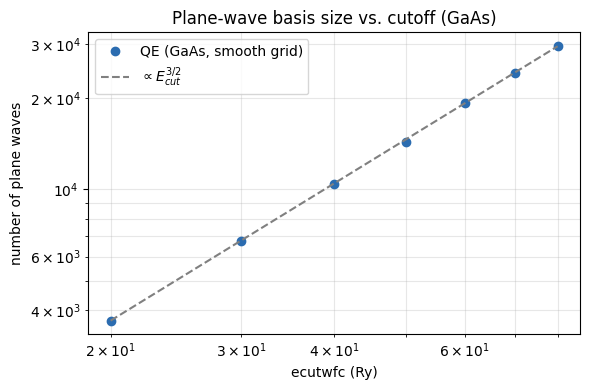

In [2]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(6, 4))
ax.loglog(ec, npw, 'o', color='#2b6cb0', label='QE (GaAs, smooth grid)')

# Reference power law normalised at the first point.
ref = npw[0] * (ec / ec[0])**1.5
ax.loglog(ec, ref, '--', color='gray', label=r'$\propto E_{cut}^{3/2}$')

ax.set_xlabel('ecutwfc (Ry)')
ax.set_ylabel('number of plane waves')
ax.set_title('Plane-wave basis size vs. cutoff (GaAs)')
ax.legend()
ax.grid(True, which='both', alpha=0.3)
fig.tight_layout()

out_png = Path('../static/img/01-basis-size.png')
out_png.parent.mkdir(parents=True, exist_ok=True)
fig.savefig(out_png, dpi=120)
plt.show()

**What you see:** the points sit right on the $E_\text{cut}^{3/2}$ line.
Going from 20 to 80 Ry multiplies `ecutwfc` by 4 and the basis size by
$4^{3/2} = 8$ (3695 → 29603 plane waves). This is *basis size*, not
*accuracy*: a bigger basis costs more but does not automatically mean a
better-converged energy — choosing `ecutwfc` for accuracy is the
convergence study in Chapter 3.